In [25]:
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import so

## Load the data

In [2]:
df = so.load_data()
so.did_prepare_data(df)
print(df.info())

questions = so.questions(df)
answers = so.answers(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5997763 entries, 0 to 5997762
Data columns (total 20 columns):
 #   Column            Dtype         
---  ------            -----         
 0   PostTypeId        int64         
 1   AcceptedAnswerId  float64       
 2   CreationDate      datetime64[ns]
 3   Score             int64         
 4   ViewCount         float64       
 5   AnswerCount       float64       
 6   CommentCount      int64         
 7   FavoriteCount     float64       
 8   OwnerUserId       float64       
 9   Title             object        
 10  Tags              object        
 11  line_count        float64       
 12  T                 int64         
 13  P                 int64         
 14  W                 int64         
 15  code              object        
 16  text              object        
 17  log_lc            float64       
 18  D                 int32         
 19  date              datetime64[ns]
dtypes: datetime64[ns](2), float64(7), int32(1), in

In [3]:
# Tags
filenames = ['java_c.csv', 'python_c.csv', 'web_c.csv']
tags = ['java', 'python', 'web']

tag_dfs = {}
for tag, filename in zip(tags, filenames):
        print(f'Loading: {tag}')
        tag_df = so.load_data(f'data/csv/tags/{filename}')
        so.did_prepare_data(tag_df, 'tags')
        tag_dfs[tag] = tag_df

Loading: java
Loading: python
Loading: web


### Propensity score

In [13]:
def propensity_scores(data, features):
    formula = 'T ~ ' + ' + '.join(s if s == 'sc_pre' else f'log_{s}' for s in features)
    print(formula)

    logit = smf.logit(formula, data=data).fit()
    data = data.copy()
    data['ps'] = logit.predict(data)

    # Weights
    data['w_user'] = np.where(data['T'] == 1, 1.0, data['ps'] / (1.0 - data['ps']))

    # Trim extreme control weights
    cap = data.loc[data['T'] == 0, 'w_user'].quantile(0.99)
    data.loc[(data['T'] == 0) & (data['w_user'] > cap), 'w_user'] = cap

    return data

In [27]:
def overlap(data):
    # Unweighted treated vs control KDE
    plt.figure()
    sns.kdeplot(data=data, x='ps', hue='T', common_norm=False)
    plt.title('Propensity score KDE (unweighted)')
    plt.xlabel('Propensity score')
    plt.show()
    plt.close()

    # Weighted control KDE vs treated KDE
    plt.figure()
    sns.kdeplot(data=data[data['T']==1], x='ps', label='Treated', common_norm=False)
    sns.kdeplot(data=data[data['T']==0], x='ps', weights='w_user', label='Control weighted', common_norm=False)
    plt.title('Propensity score KDE (weighted)')
    plt.xlabel('Propensity score')
    plt.show()
    plt.close()

### Standardized mean difference

In [5]:
def wmean(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    return np.sum(w * x) / np.sum(w)

def wvar(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    mu = wmean(x, w)
    return np.sum(w * (x - mu)**2) / np.sum(w)

def smd(df_user, xcol, treat_col="T", wcol=None):
    """
    Balance: treated unweighted, controls weighted by w_user.
    """
    t = df_user[treat_col] == 1
    c = ~t

    x_t = df_user.loc[t, xcol].to_numpy()
    x_c = df_user.loc[c, xcol].to_numpy()

    # Treated weights are 1
    if wcol is not None:
        w_c = df_user.loc[c, wcol].to_numpy()

    mt = x_t.mean()
    if wcol is not None:
        mc = wmean(x_c, w_c)
    else:
        mc = x_c.mean()

    vt = x_t.var(ddof=0)
    if wcol is not None:
        vc = wvar(x_c, w_c)
    else:
        vc = x_c.var(ddof=0)

    denom = np.sqrt((vt + vc) / 2.0)
    return (mt - mc) / denom if denom > 0 else np.nan

## Match and fit

In [6]:
def clean(data):
    data = data.dropna(subset=['OwnerUserId']).copy()
    data['OwnerUserId'] = data['OwnerUserId'].astype(int)
    return data

In [7]:
def regression(data, outcome):
    start_dates, masks = so.rolling_window_masks(data, data_column='date', normalized=True, window_days=30)    

    X, y = so.did_design_matrix(f'{outcome}_bar', data)
    res = so.did_wls(data, X, y, masks, start_dates, outcome)
    return res

Processing: questions
T ~ log_act_pre + log_comm_pre + log_ans_pre + log_view_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.669214
         Iterations 6
Balance: --------------
***********
Before matching:  act_pre -0.05099336655987148
After matching:  act_pre 0.00983004560437655
Balance: --------------
***********
Before matching:  comm_pre -0.06559268450634763
After matching:  comm_pre -0.001423931271580947
Balance: --------------
***********
Before matching:  ans_pre -0.07061980103119883
After matching:  ans_pre -0.000725114425379759
Balance: --------------
***********
Before matching:  view_pre -0.176747044830564
After matching:  view_pre -0.046031934025666084
Balance: --------------
***********
Before matching:  sc_pre -0.12097008728306989
After matching:  sc_pre -0.001663967796039834
Overlap: --------------
      count      mean       std           min        1%        5%       10%  \
T                                                       

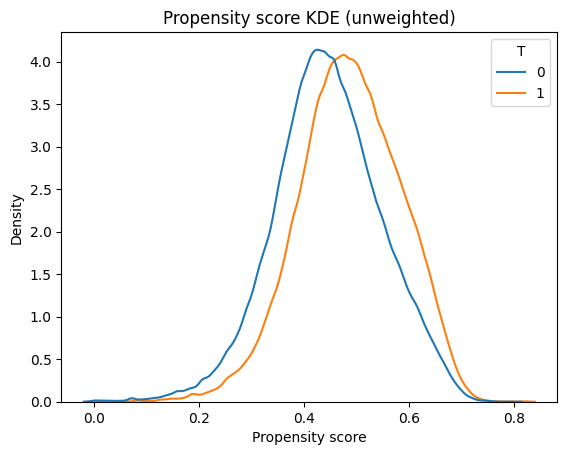

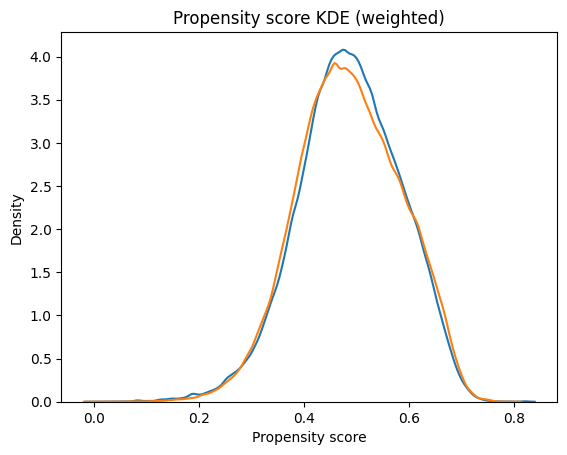

Processing: log_lc


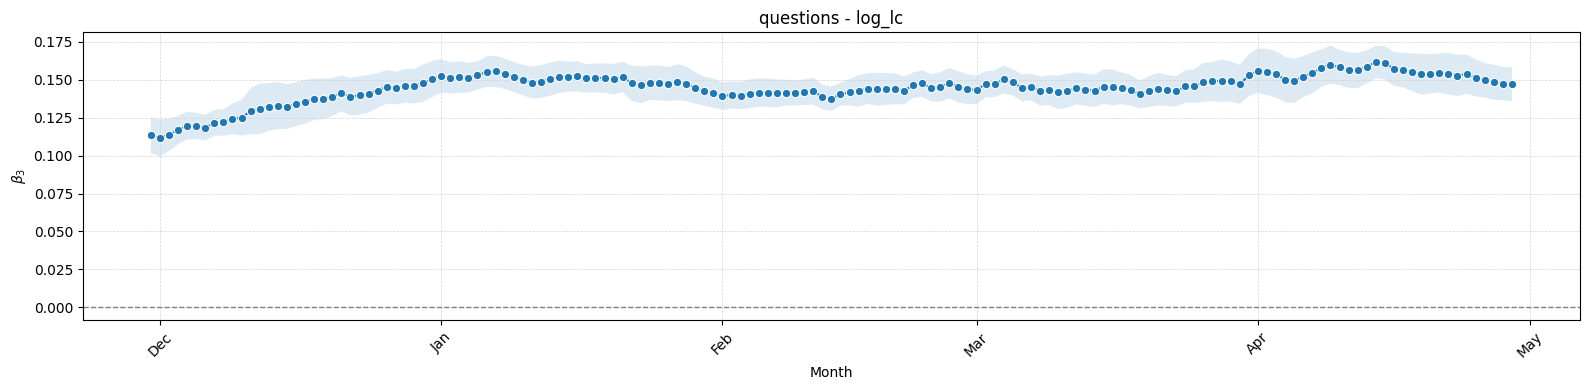

Processing: answers
T ~ log_act_pre + log_comm_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.684313
         Iterations 5
Balance: --------------
***********
Before matching:  act_pre -0.07389468227630674
After matching:  act_pre 0.04763792343566204
Balance: --------------
***********
Before matching:  comm_pre -0.1062233707698399
After matching:  comm_pre 0.021168408274446656
Balance: --------------
***********
Before matching:  sc_pre -0.13275263737705004
After matching:  sc_pre -0.003596697153991446
Overlap: --------------
       count      mean       std       min        1%        5%       10%  \
T                                                                          
0  1456888.0  0.454449  0.054132  0.077746  0.280741  0.371172  0.397962   
1  1238188.0  0.465282  0.047841  0.150418  0.332089  0.393225  0.414915   

        50%       90%       95%       99%       max  
T                                                    
0  0.462471  0.

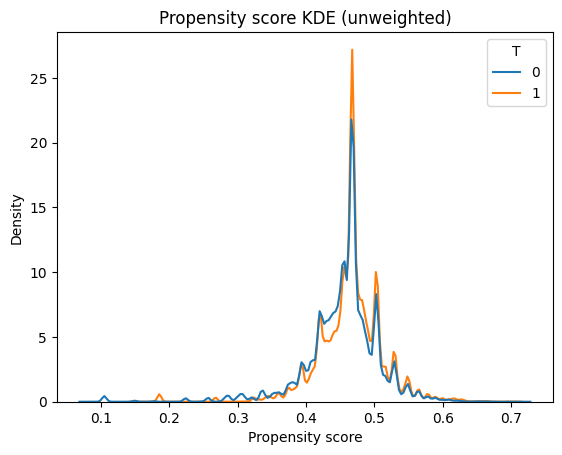

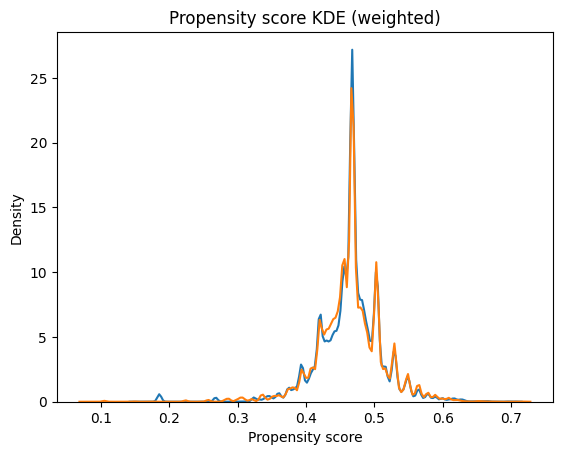

Processing: log_lc


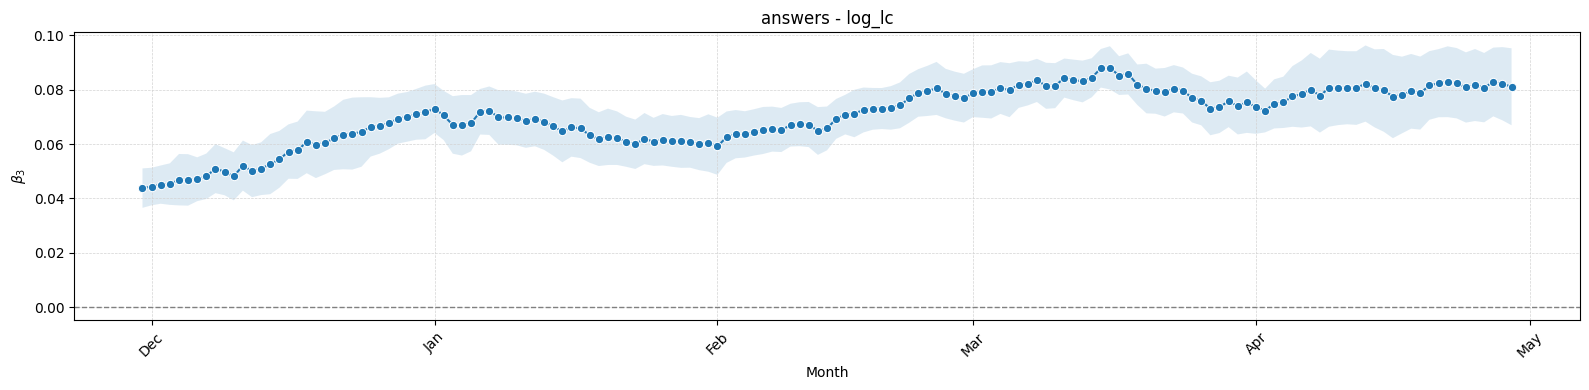

Processing: java
T ~ log_act_pre + log_comm_pre + log_ans_pre + log_view_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.670560
         Iterations 6
Balance: --------------
***********
Before matching:  act_pre -0.04679208868959764
After matching:  act_pre 0.03349109175960677
Balance: --------------
***********
Before matching:  comm_pre -0.03784018816045439
After matching:  comm_pre 0.04344547749658587
Balance: --------------
***********
Before matching:  ans_pre -0.09081484809316039
After matching:  ans_pre 0.016388235043878183
Balance: --------------
***********
Before matching:  view_pre -0.1637629868897701
After matching:  view_pre -0.02370423853491728
Balance: --------------
***********
Before matching:  sc_pre -0.1315480368207499
After matching:  sc_pre -0.00912972278728522
Overlap: --------------
     count      mean       std       min        1%        5%       10%  \
T                                                                      

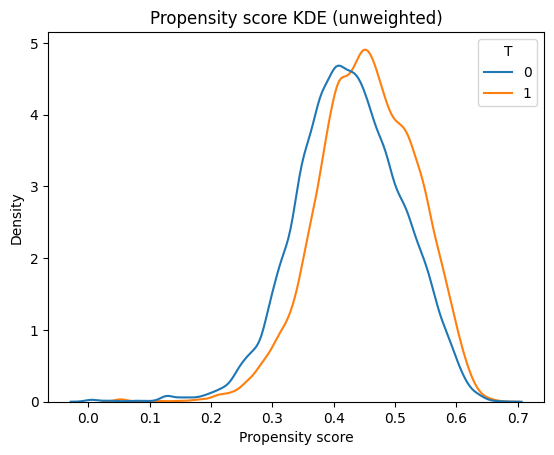

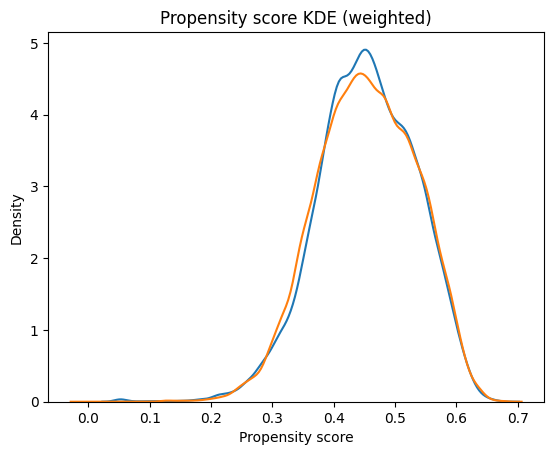

Processing: log_lc


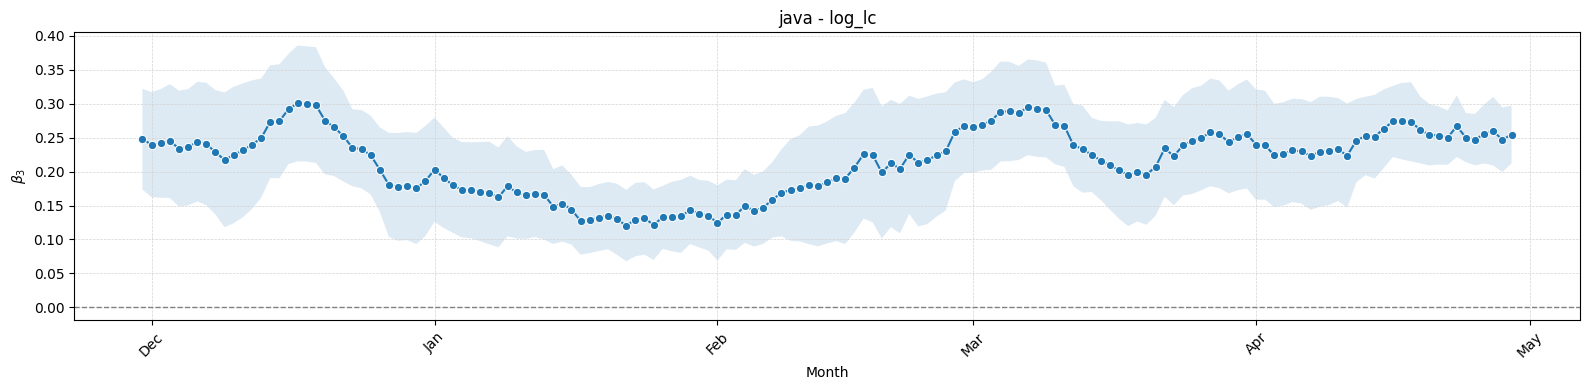

Processing: log_loc


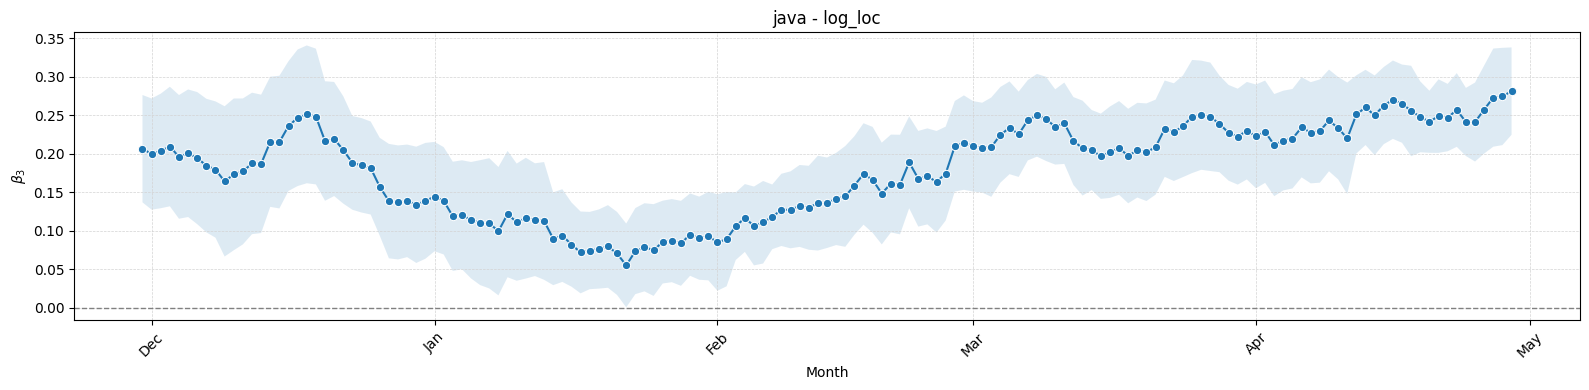

Processing: Medium


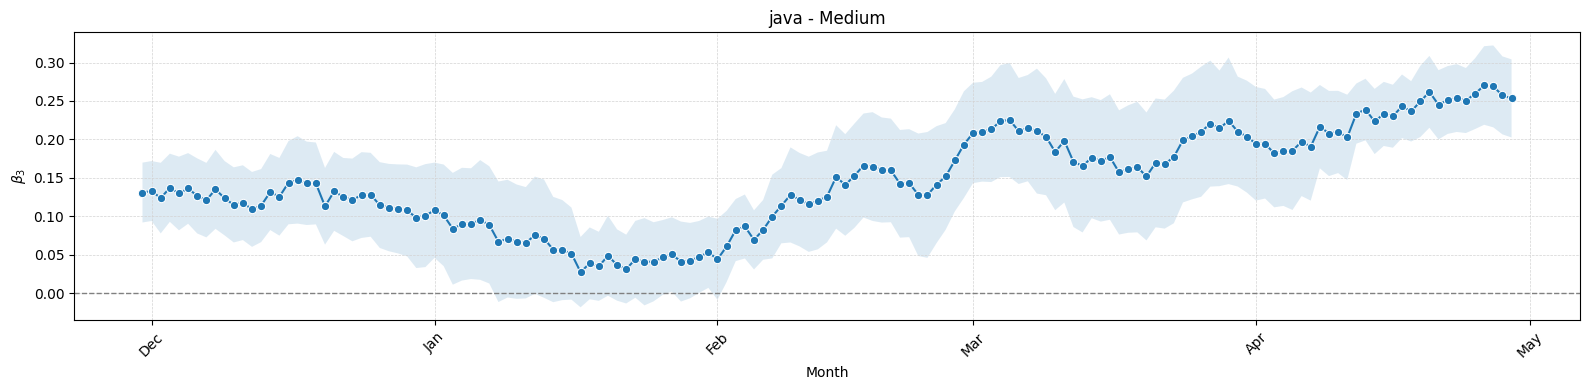

Processing: python
T ~ log_act_pre + log_comm_pre + log_ans_pre + log_view_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.664579
         Iterations 5
Balance: --------------
***********
Before matching:  act_pre -0.08014572333659463
After matching:  act_pre 0.007966511889626778
Balance: --------------
***********
Before matching:  comm_pre -0.10181220116104218
After matching:  comm_pre -0.004521706402776296
Balance: --------------
***********
Before matching:  ans_pre -0.08766647516837349
After matching:  ans_pre 0.0034904209733533234
Balance: --------------
***********
Before matching:  view_pre -0.22529428630048515
After matching:  view_pre -0.042635077199197326
Balance: --------------
***********
Before matching:  sc_pre -0.1718354245531565
After matching:  sc_pre 0.006140352107823291
Overlap: --------------
      count      mean       std       min        1%        5%       10%  \
T                                                             

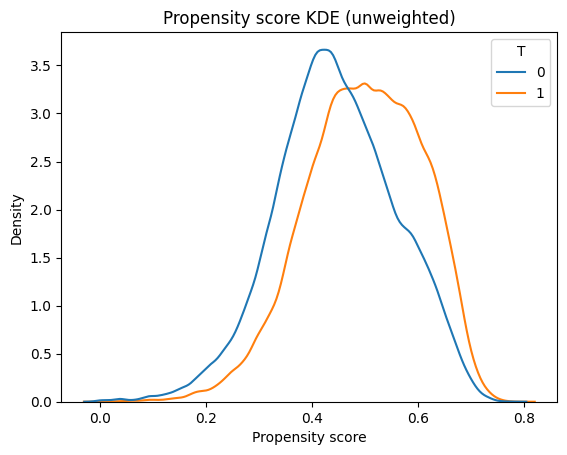

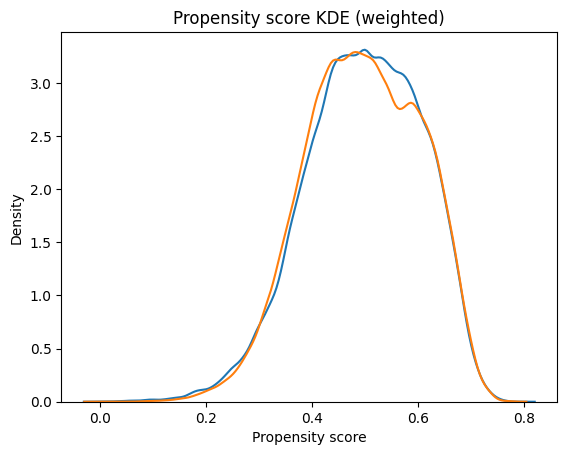

Processing: log_lc


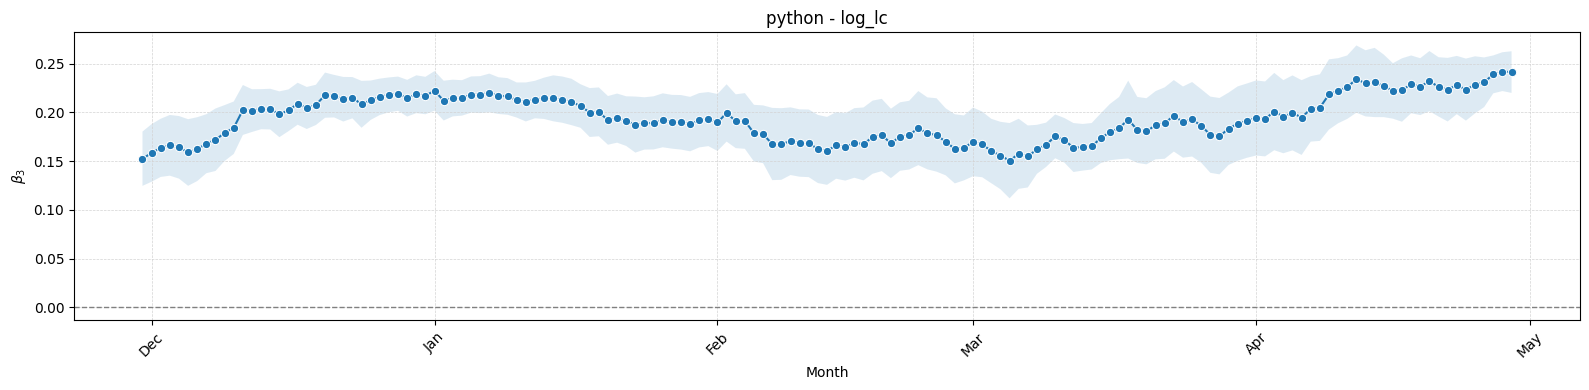

Processing: log_loc


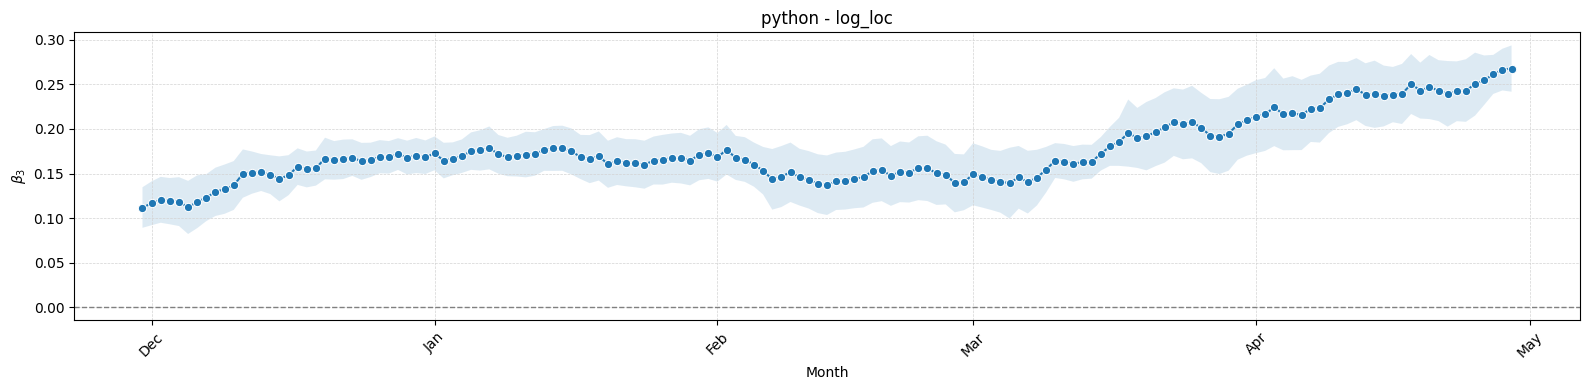

Processing: Medium


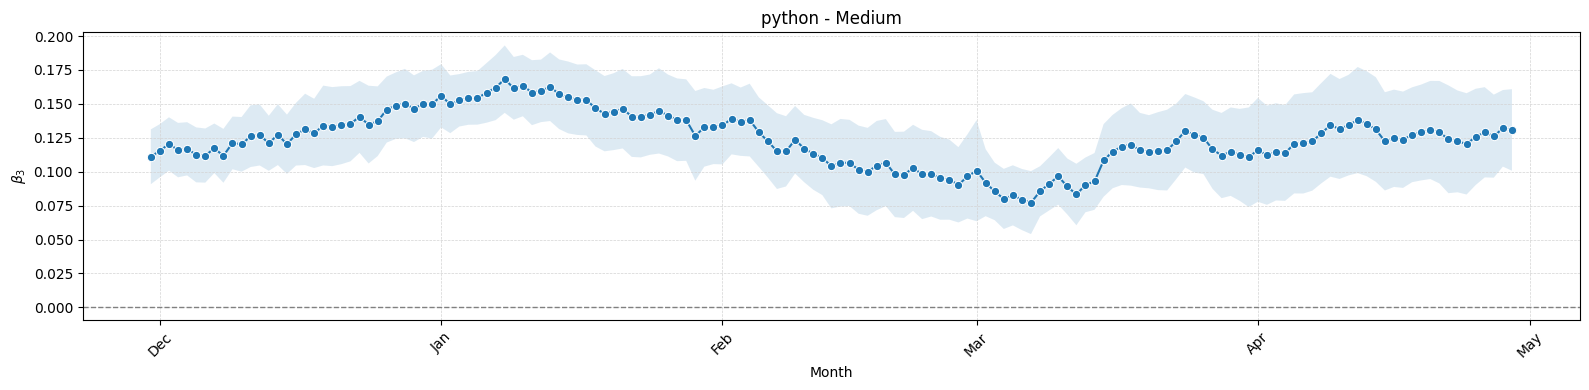

Processing: web
T ~ log_act_pre + log_comm_pre + log_ans_pre + log_view_pre + sc_pre
Optimization terminated successfully.
         Current function value: 0.667697
         Iterations 6
Balance: --------------
***********
Before matching:  act_pre -0.10093175047550171
After matching:  act_pre -0.008599631939089874
Balance: --------------
***********
Before matching:  comm_pre -0.11703421886208593
After matching:  comm_pre -0.024274092141873496
Balance: --------------
***********
Before matching:  ans_pre -0.12966765519884518
After matching:  ans_pre -0.026074437171769077
Balance: --------------
***********
Before matching:  view_pre -0.20530506812971203
After matching:  view_pre -0.0549718982386556
Balance: --------------
***********
Before matching:  sc_pre -0.1523784303785937
After matching:  sc_pre -9.252379018837266e-05
Overlap: --------------
      count      mean       std           min        1%        5%       10%  \
T                                                           

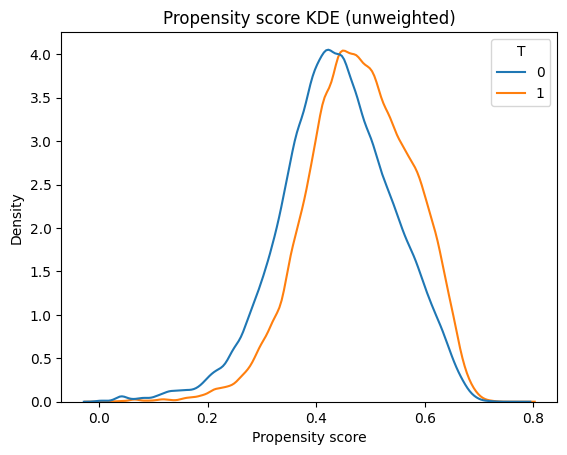

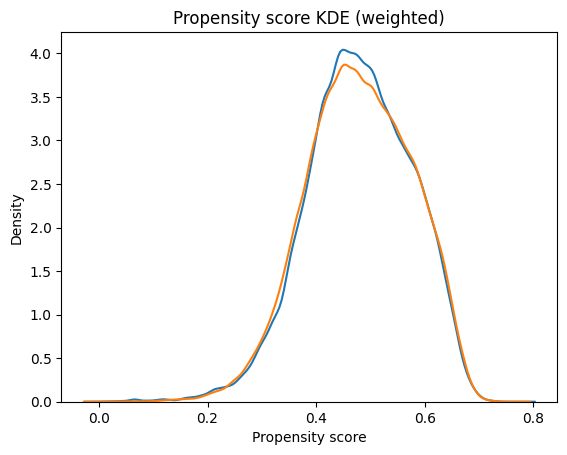

Processing: log_lc


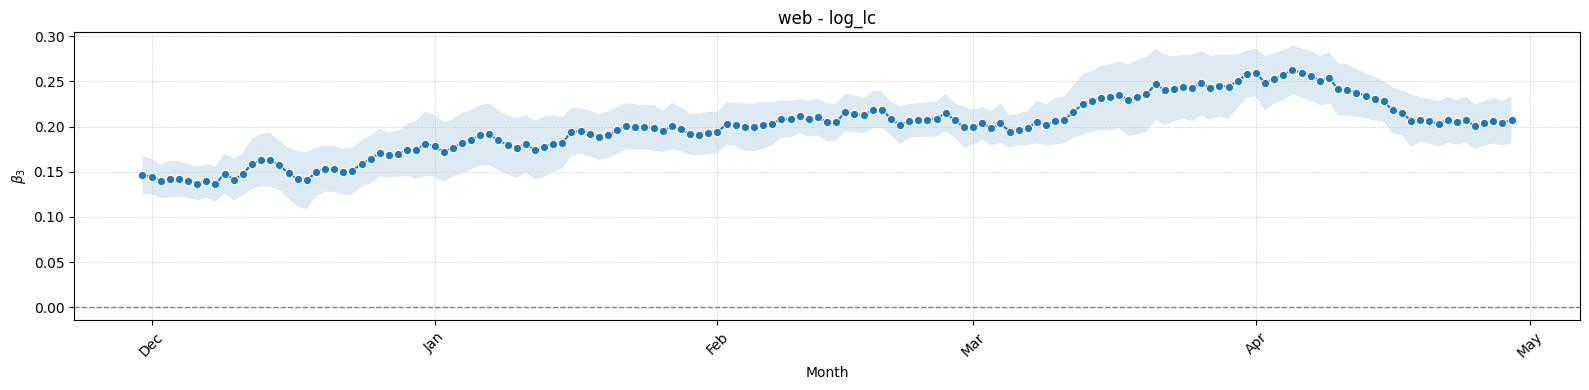

Processing: log_loc


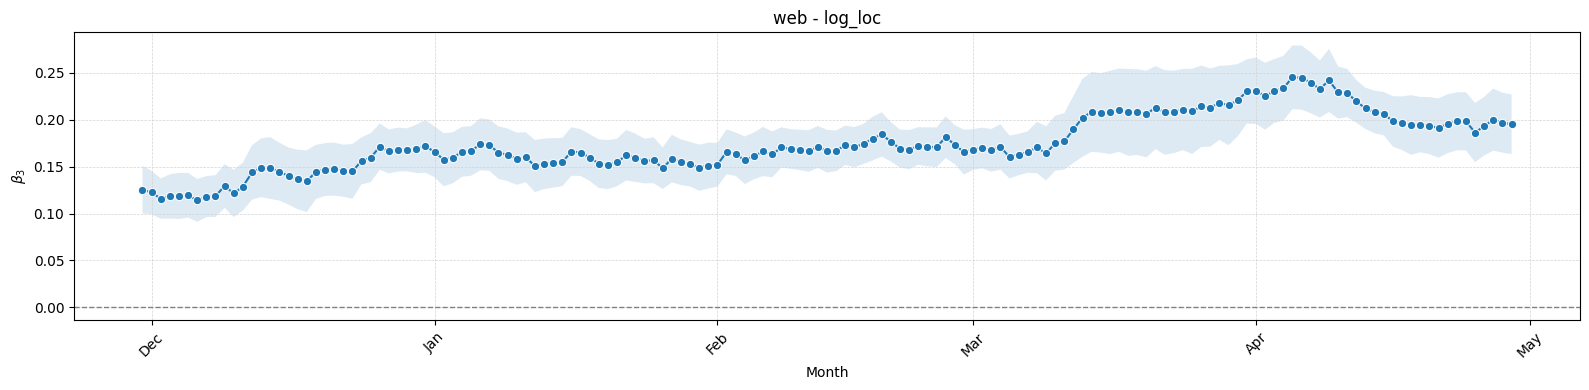

Processing: Medium


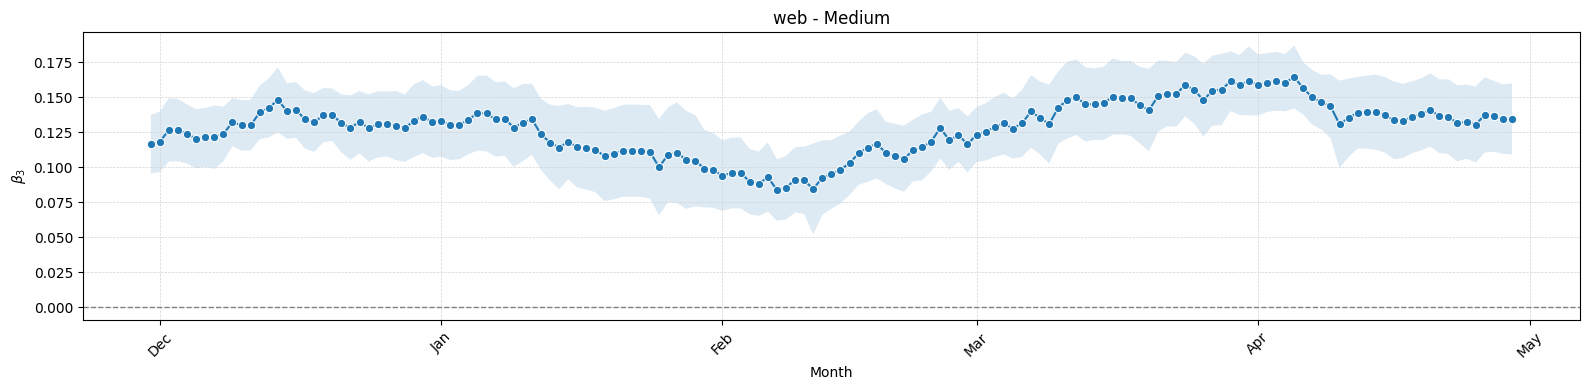

In [28]:
dfs = {'questions': questions, 'answers': answers} | tag_dfs
targets = ['log_lc', 'log_loc', 'Medium']
outcomes = {'questions': ['log_lc'], 'answers': ['log_lc'], 'java': targets, 'python': targets, 'web': targets}
q_features = ['act_pre', 'comm_pre', 'ans_pre', 'view_pre', 'sc_pre']
a_features = ['act_pre', 'comm_pre', 'sc_pre']

for type in dfs:
    print(f'Processing: {type}')
    data = clean(dfs[type])

    pre = dfs[type][dfs[type]['P'] == 0]    

    u_pre = (pre.groupby(['OwnerUserId', 'T']).agg(
        act_pre=('PostTypeId', 'size'),
        comm_pre=('CommentCount', 'sum'),
        ans_pre=('AnswerCount', 'sum'),
        view_pre=('ViewCount', 'sum'),        
        sc_pre=('Score', 'sum')).reset_index()
    )

    if type == 'answers':
        features = a_features
    else:
        features = q_features

    # log transforms
    for c in features:
        if c == 'sc_pre':
            continue
        u_pre[f'log_{c}'] = np.log1p(u_pre[c])

    df_uf = dfs[type].merge(u_pre, on=['OwnerUserId', 'T'], how='inner')
    
    # match
    df_uf = propensity_scores(df_uf, features)

    # check for balance
    for x in features:
        print('Balance: --------------\n***********')
        print('Before matching: ', x, smd(df_uf, x))
        print('After matching: ', x, smd(df_uf, x, wcol='w_user'))

    # overlap
    print('Overlap: --------------')
    print(df_uf.groupby('T')['ps'].describe(percentiles=[.01,.05,.1,.5,.9,.95,.99]))
    overlap(df_uf)

    # fit
    daily = so.prepare_daily_data(df_uf, outcomes[type], 'w_user')
    for outcome in outcomes[type]:
        print(f'Processing: {outcome}')
        res = regression(daily, outcome)
        so.plot_did(res, f'{type} - {outcome}', 'temp/temp.pdf')